In [1]:
"""Imports"""
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import tqdm

import src.utils as utils
import src.plots as plots
import src.models as models

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
  
else:
    dev = "cpu"
    print(f"Using device: {dev}")

/home/ids/edabier/miniconda3/envs/hsu/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda:0


HSI of shape (285, 110, 110) with 4 endmembers


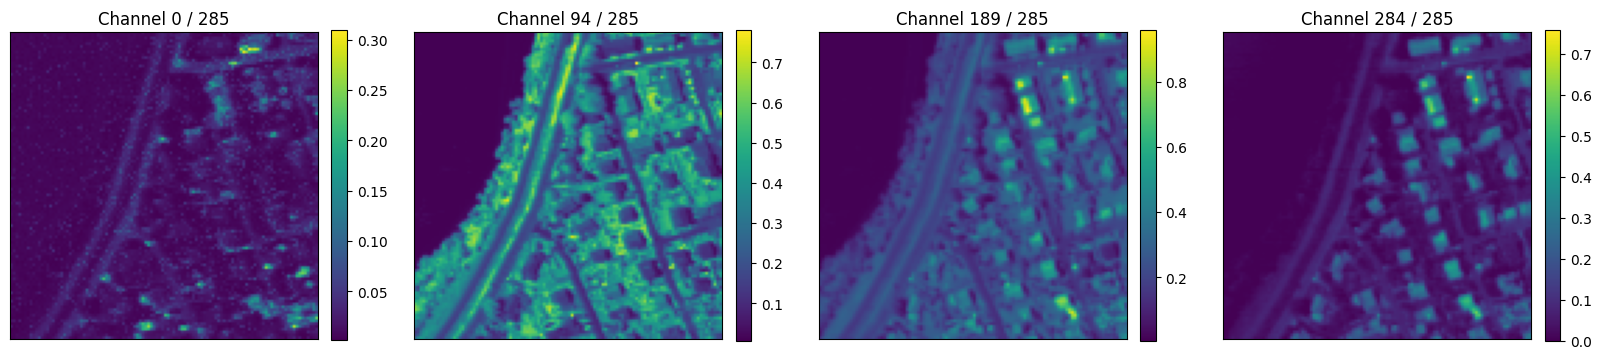

In [2]:
"""Load the HSI and visualize it"""
dataset = "apex"
Y_init, A_init, E_init, wavelengths = utils.load_hsi(dataset, normalize_Y=True)
B, c, H = Y_init.shape[1], A_init.shape[1], Y_init.shape[-1]

print(f"HSI of shape {B, H, H} with {c} endmembers")
plots.plot_hsi(Y_init)

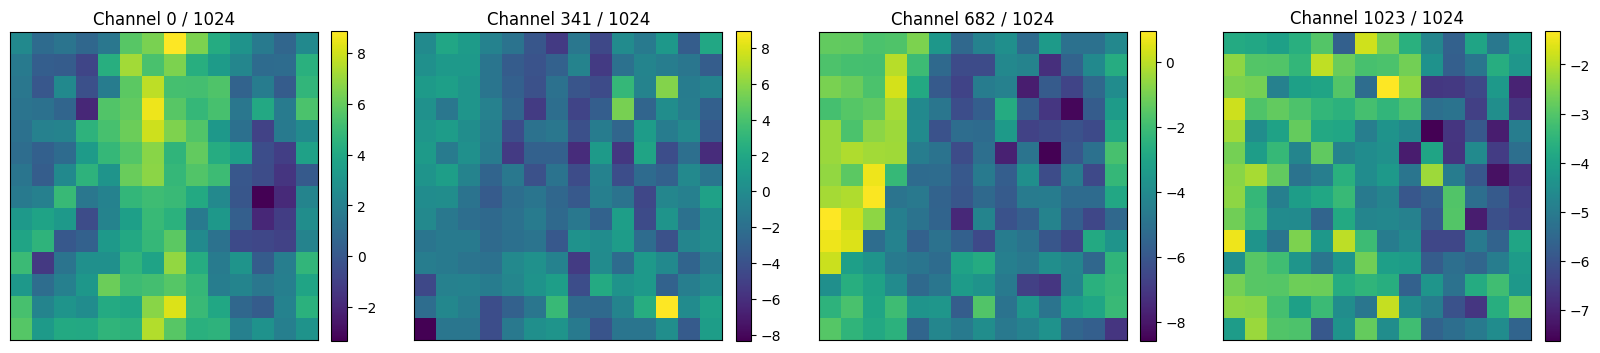

In [ ]:
"""Extract features from Y_init using DOFA"""
dofa, Y_dofa, A_dofa, new_H = models.create_dofa(Y_init, A_init, path="path/to/DOFA/checkpoints")
features = models.extract_features(dofa, Y_dofa, wavelengths)
D, alpha, _ = features.shape

plots.plot_hsi(features)

100%|██████████| 200/200 [00:38<00:00,  5.16it/s]


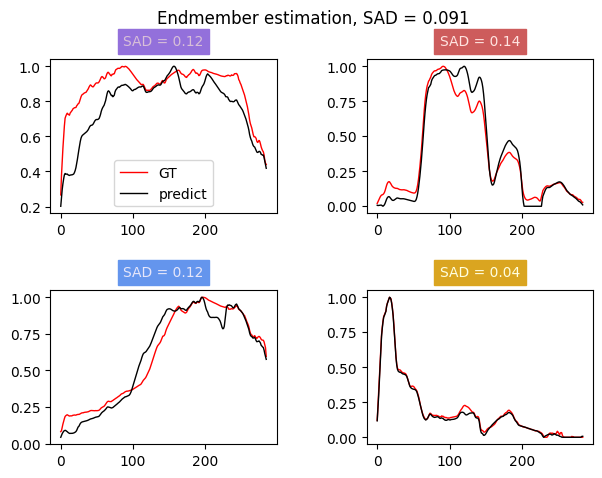

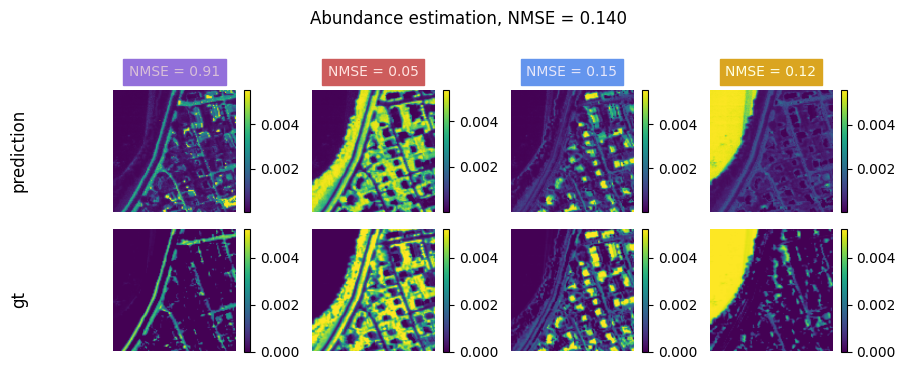

In [4]:
"""Train an unmixing network using DOFA features"""

model = models.Unmixing_from_features(D=D, alpha=alpha, B=B, c=c)
model.apply(model.weights_init)
model = models.init_decoder_weights(model, Y_dofa/Y_dofa.max(), c)

epochs, lr = 200, 0.002
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.999), weight_decay=0.18)

for epoch in tqdm(range(epochs)):

    optimizer.zero_grad()
    
    Y = Y_dofa.to(dev)

    features = models.extract_features(dofa, Y, wavelengths)
    E_hat, A_hat, Y_hat = model(features)
    
    loss = model.loss(Y, Y_hat, A_hat, E_hat)

    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
    optimizer.step()
    
    with torch.no_grad():
        constraints = models.weightConstraint()
        model.decoder.apply(constraints)
            
model.eval()

with torch.no_grad():
    features = models.extract_features(dofa, Y_dofa, wavelengths)
    E_hat, A_hat, Y_hat = model(features)
    sad, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_dofa, E_init)

In [ ]:
"""Use SpectralEarth's adapter to map HSI to a consistent amount of spectral bands"""
spectralearth = models.create_spectralearth(dev, path="path/to/SpectralEarth/data")
Y_adapted = models.spectral_adapter(spectralearth, Y_init)
print(f"Adapted HSI is now of shape {Y_adapted.shape}")

Adapted HSI is now of shape torch.Size([1, 128, 110, 110])
